In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, GroupKFold, cross_val_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.compose import TransformedTargetRegressor
import plotly.express as px
import os
import warnings
import shap
warnings.filterwarnings('ignore')
%matplotlib inline
print(f"📂 Buscando datos en: {os.getcwd()}")

📂 Buscando datos en: C:\Users\nicolas.pena


In [2]:
def safe_expm1(x):
    return np.expm1(np.clip(x, a_min=None, a_max=20.0))

In [3]:
archivos = [f for f in os.listdir('.') if "Sistema_PVA" in f and (f.endswith('.xlsx') or f.endswith('.csv'))]

archivo_objetivo = archivos[0]

if archivo_objetivo.endswith('.xlsx'):
    df = pd.read_excel(archivo_objetivo, skiprows=2)
else:
    df = pd.read_csv(archivo_objetivo, skiprows=2)
    
df.columns = df.columns.str.strip()

col_young, col_error = 'Young Modulus (Kpa)', 'Error Absoluto'
features_ia = [
    'PEGDA (%)', 
    'PVA (%)', 
    'LAP (%)', 
    'Tiempo Sumergido (min)', 
]

df['Valor_Temp'] = df[col_young].astype(str).str.strip().str.upper()
df_inicial = df[~df['Valor_Temp'].isin(['NG', 'ERROR', 'NAN', 'NONE', 'NULL', ''])].copy()

for col in features_ia + [col_young, col_error]:
    if col in df_inicial.columns:
        df_inicial[col] = pd.to_numeric(df_inicial[col], errors='coerce')

df_inicial = df_inicial.dropna(subset=[col_young] + features_ia)
df_inicial = df_inicial[df_inicial[col_young] > 0].drop(columns=['Valor_Temp'])

In [4]:
# ======================================
# LIMPIEZA DE OUTLIERS
# ======================================
def eliminar_outliers_mad(grupo, threshold=25.0):
    col_err_rel = 'Error Relativo (%)'
    mascara_validos = grupo[col_err_rel] <= threshold
    return grupo[mascara_validos]

df_super_limpio = (
    df_inicial
    .groupby(['PEGDA (%)', 'PVA (%)', 'LAP (%)', 'Tiempo Sumergido (min)'], group_keys=False)
    .apply(eliminar_outliers_mad)
)

n_antes = len(df_inicial)
n_despues = len(df_super_limpio)

print(f"Muestras iniciales tras limpieza: {n_antes}")
print(f"Muestras finales tras outliers:   {n_despues}")
print(f"Eliminadas: {n_antes - n_despues}")

Muestras iniciales tras limpieza: 263
Muestras finales tras outliers:   215
Eliminadas: 48


In [5]:
# ======================================
# DEFINICION DE X, y Y GRUPOS
# ======================================
df_super_limpio = df_super_limpio.copy()

df_super_limpio['Receta_ID'] = (
    df_super_limpio['PEGDA (%)'].astype(str) + "_" +
    df_super_limpio['PVA (%)'].astype(str) + "_" +
    df_super_limpio['LAP (%)'].astype(str)
)

X = df_super_limpio[features_ia]
y = df_super_limpio[col_young]
grupos = df_super_limpio['Receta_ID']

RANDOM = 67

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM)
train_idx, test_idx = next(gss.split(X, y, groups=grupos))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Muestras:", len(df_super_limpio))
print("Recetas unicas:", df_super_limpio['Receta_ID'].nunique())
print(f"Entrenamiento: {len(X_train)} muestras | Testeo: {len(X_test)} muestras")

print("========== VARIABLES USADAS ==========")
for col in X.columns:
    print(col)

Muestras: 215
Recetas unicas: 78
Entrenamiento: 174 muestras | Testeo: 41 muestras
========== VARIABLES USADAS ==========
PEGDA (%)
PVA (%)
LAP (%)
Tiempo Sumergido (min)


In [6]:
# ======================================
# ENTRENAMIENTO EXTRATREES
# ======================================
from sklearn.ensemble import ExtraTreesRegressor

print("\nConstruyendo y optimizando ExtraTrees...")

extra_log = TransformedTargetRegressor(
    regressor=ExtraTreesRegressor(
        random_state=RANDOM,
        n_jobs=-1
    ),
    func=np.log1p,
    inverse_func=safe_expm1
)

param_grid = {
    'regressor__n_estimators': [300, 400, 600, 800],
    'regressor__max_depth': [6, 8, 10, 12],
    'regressor__min_samples_split': [4, 6, 8, 10],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_features': [0.7, 0.8, 0.9, 1.0],
    'regressor__bootstrap': [False]
}

group_kfold = GroupKFold(n_splits=5)

grid_extra = GridSearchCV(
    extra_log,
    param_grid,
    cv=group_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grupos_train = grupos.loc[X_train.index]

grid_extra.fit(
    X_train,
    y_train,
    groups=grupos_train
)

best_extra = grid_extra.best_estimator_

y_pred_extra = best_extra.predict(X_test)
y_pred_extra_train = best_extra.predict(X_train)

r2_extra = r2_score(y_test, y_pred_extra)
mae_extra = mean_absolute_error(y_test, y_pred_extra)
rmse_extra = np.sqrt(mean_squared_error(y_test, y_pred_extra))

print("\nEntrenamiento ExtraTrees completado.")
print("Mejores hiperparametros:", grid_extra.best_params_)
print(f"R2 ExtraTrees Test: {r2_extra:.3f}")
print(f"MAE ExtraTrees Test: {mae_extra:.3f} kPa")
print(f"RMSE ExtraTrees Test: {rmse_extra:.3f} kPa")


Construyendo y optimizando ExtraTrees...
Fitting 5 folds for each of 512 candidates, totalling 2560 fits

Entrenamiento ExtraTrees completado.
Mejores hiperparametros: {'regressor__bootstrap': False, 'regressor__max_depth': 12, 'regressor__max_features': 0.7, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 4, 'regressor__n_estimators': 300}
R2 ExtraTrees Test: 0.811
MAE ExtraTrees Test: 93.427 kPa
RMSE ExtraTrees Test: 166.681 kPa


In [7]:
# ======================================
# EXTRATREES - VALIDACION EN 30 SPLITS
# ======================================
scores_r2_extra = []
scores_mae_extra = []

best_params_extra = {
    key.replace('regressor__', ''): value
    for key, value in grid_extra.best_params_.items()
}

gss_multi = GroupShuffleSplit(
    n_splits=30,
    test_size=0.2,
    random_state=RANDOM
)

for i, (train_idx_tmp, test_idx_tmp) in enumerate(gss_multi.split(X, y, groups=grupos), start=1):

    X_train_tmp, X_test_tmp = X.iloc[train_idx_tmp], X.iloc[test_idx_tmp]
    y_train_tmp, y_test_tmp = y.iloc[train_idx_tmp], y.iloc[test_idx_tmp]

    extra_model = TransformedTargetRegressor(
        regressor=ExtraTreesRegressor(
            **best_params_extra,
            random_state=RANDOM,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=safe_expm1
    )

    extra_model.fit(X_train_tmp, y_train_tmp)

    y_pred_tmp = extra_model.predict(X_test_tmp)

    r2_tmp = r2_score(y_test_tmp, y_pred_tmp)
    mae_tmp = mean_absolute_error(y_test_tmp, y_pred_tmp)

    scores_r2_extra.append(r2_tmp)
    scores_mae_extra.append(mae_tmp)

    print(f"ExtraTrees Split {i:02d}: R2 = {r2_tmp:.4f} | MAE = {mae_tmp:.2f} KPa")

scores_r2_extra = np.array(scores_r2_extra)
scores_mae_extra = np.array(scores_mae_extra)

print("\n==============================")
print("RESUMEN EXTRATREES - 30 SPLITS")
print("==============================")
print(f"R2 medio: {scores_r2_extra.mean():.4f}")
print(f"R2 std:   {scores_r2_extra.std(ddof=1):.4f}")
print(f"R2 min:   {scores_r2_extra.min():.4f}")
print(f"R2 max:   {scores_r2_extra.max():.4f}")
print(f"MAE medio: {scores_mae_extra.mean():.2f} KPa")
print(f"MAE std:   {scores_mae_extra.std(ddof=1):.2f} KPa")

ExtraTrees Split 01: R2 = 0.8108 | MAE = 93.43 KPa
ExtraTrees Split 02: R2 = 0.5290 | MAE = 162.09 KPa
ExtraTrees Split 03: R2 = 0.1632 | MAE = 223.62 KPa
ExtraTrees Split 04: R2 = 0.6194 | MAE = 121.20 KPa
ExtraTrees Split 05: R2 = 0.6289 | MAE = 156.84 KPa
ExtraTrees Split 06: R2 = 0.6168 | MAE = 169.97 KPa
ExtraTrees Split 07: R2 = 0.4805 | MAE = 181.68 KPa
ExtraTrees Split 08: R2 = 0.7715 | MAE = 105.56 KPa
ExtraTrees Split 09: R2 = 0.5069 | MAE = 184.38 KPa
ExtraTrees Split 10: R2 = 0.2715 | MAE = 251.89 KPa
ExtraTrees Split 11: R2 = 0.6833 | MAE = 134.96 KPa
ExtraTrees Split 12: R2 = 0.7084 | MAE = 105.56 KPa
ExtraTrees Split 13: R2 = 0.5078 | MAE = 186.52 KPa
ExtraTrees Split 14: R2 = 0.6972 | MAE = 111.02 KPa
ExtraTrees Split 15: R2 = 0.6529 | MAE = 132.48 KPa
ExtraTrees Split 16: R2 = 0.3444 | MAE = 116.40 KPa
ExtraTrees Split 17: R2 = 0.2961 | MAE = 124.63 KPa
ExtraTrees Split 18: R2 = 0.5317 | MAE = 136.21 KPa
ExtraTrees Split 19: R2 = 0.7709 | MAE = 128.86 KPa
ExtraTrees Sp

In [8]:
# ======================================
# ENTRENAMIENTO RANDOM FOREST OPTIMIZADO
# ======================================
from sklearn.ensemble import RandomForestRegressor

print("\nConstruyendo y optimizando Random Forest...")

rf_log = TransformedTargetRegressor(
    regressor=RandomForestRegressor(
        random_state=RANDOM,
        n_jobs=-1
    ),
    func=np.log1p,
    inverse_func=safe_expm1
)

param_grid_rf = {
    'regressor__n_estimators': [200, 400, 800],
    'regressor__max_depth': [None, 4, 6, 8, 12],
    'regressor__min_samples_split': [2, 4, 6],
    'regressor__min_samples_leaf': [1, 2, 3],
    'regressor__max_features': [0.6, 0.8, 1.0],
    'regressor__bootstrap': [True]
}

group_kfold = GroupKFold(n_splits=5)

grid_rf = GridSearchCV(
    rf_log,
    param_grid_rf,
    cv=group_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grupos_train = grupos.loc[X_train.index]

grid_rf.fit(
    X_train,
    y_train,
    groups=grupos_train
)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_rf_train = best_rf.predict(X_train)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\nEntrenamiento Random Forest completado.")
print("Mejores hiperparametros:", grid_rf.best_params_)
print(f"R2 Random Forest Test: {r2_rf:.3f}")
print(f"MAE Random Forest Test: {mae_rf:.3f} kPa")
print(f"RMSE Random Forest Test: {rmse_rf:.3f} kPa")


Construyendo y optimizando Random Forest...
Fitting 5 folds for each of 405 candidates, totalling 2025 fits

Entrenamiento Random Forest completado.
Mejores hiperparametros: {'regressor__bootstrap': True, 'regressor__max_depth': 8, 'regressor__max_features': 0.6, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
R2 Random Forest Test: 0.620
MAE Random Forest Test: 119.555 kPa
RMSE Random Forest Test: 236.201 kPa


In [9]:
# ======================================
# RANDOM FOREST - VALIDACION EN 30 SPLITS
# ======================================
scores_r2_rf = []
scores_mae_rf = []

best_params_rf = {
    key.replace('regressor__', ''): value
    for key, value in grid_rf.best_params_.items()
}

gss_multi = GroupShuffleSplit(
    n_splits=30,
    test_size=0.2,
    random_state=RANDOM
)

for i, (train_idx_tmp, test_idx_tmp) in enumerate(gss_multi.split(X, y, groups=grupos), start=1):

    X_train_tmp, X_test_tmp = X.iloc[train_idx_tmp], X.iloc[test_idx_tmp]
    y_train_tmp, y_test_tmp = y.iloc[train_idx_tmp], y.iloc[test_idx_tmp]

    rf_model = TransformedTargetRegressor(
        regressor=RandomForestRegressor(
            **best_params_rf,
            random_state=RANDOM,
            n_jobs=-1
        ),
        func=np.log1p,
        inverse_func=safe_expm1
    )

    rf_model.fit(X_train_tmp, y_train_tmp)

    y_pred_tmp = rf_model.predict(X_test_tmp)

    r2_tmp = r2_score(y_test_tmp, y_pred_tmp)
    mae_tmp = mean_absolute_error(y_test_tmp, y_pred_tmp)

    scores_r2_rf.append(r2_tmp)
    scores_mae_rf.append(mae_tmp)

    print(f"RF Split {i:02d}: R2 = {r2_tmp:.3f} | MAE = {mae_tmp:.3f} kPa")

scores_r2_rf = np.array(scores_r2_rf)
scores_mae_rf = np.array(scores_mae_rf)

print("\n==============================")
print("RESUMEN RANDOM FOREST - 30 SPLITS")
print("==============================")
print(f"R2 medio: {scores_r2_rf.mean():.4f}")
print(f"R2 std:   {scores_r2_rf.std(ddof=1):.4f}")
print(f"R2 min:   {scores_r2_rf.min():.4f}")
print(f"R2 max:   {scores_r2_rf.max():.4f}")
print(f"MAE medio: {scores_mae_rf.mean():.2f} KPa")
print(f"MAE std:   {scores_mae_rf.std(ddof=1):.2f} KPa")

RF Split 01: R2 = 0.620 | MAE = 119.555 kPa
RF Split 02: R2 = 0.556 | MAE = 161.759 kPa
RF Split 03: R2 = 0.163 | MAE = 229.229 kPa
RF Split 04: R2 = 0.497 | MAE = 134.170 kPa
RF Split 05: R2 = 0.531 | MAE = 183.331 kPa
RF Split 06: R2 = 0.423 | MAE = 200.862 kPa
RF Split 07: R2 = 0.354 | MAE = 200.132 kPa
RF Split 08: R2 = 0.653 | MAE = 124.213 kPa
RF Split 09: R2 = 0.312 | MAE = 215.154 kPa
RF Split 10: R2 = 0.241 | MAE = 257.558 kPa
RF Split 11: R2 = 0.634 | MAE = 146.616 kPa
RF Split 12: R2 = 0.673 | MAE = 107.860 kPa
RF Split 13: R2 = 0.379 | MAE = 214.030 kPa
RF Split 14: R2 = 0.569 | MAE = 128.637 kPa
RF Split 15: R2 = 0.586 | MAE = 155.305 kPa
RF Split 16: R2 = 0.231 | MAE = 125.245 kPa
RF Split 17: R2 = 0.111 | MAE = 148.027 kPa
RF Split 18: R2 = 0.450 | MAE = 152.484 kPa
RF Split 19: R2 = 0.635 | MAE = 157.368 kPa
RF Split 20: R2 = 0.249 | MAE = 247.400 kPa
RF Split 21: R2 = 0.629 | MAE = 142.053 kPa
RF Split 22: R2 = 0.415 | MAE = 166.017 kPa
RF Split 23: R2 = 0.391 | MAE = 

In [10]:
# ======================================
# ENTRENAMIENTO XGBOOST
# ======================================
from xgboost import XGBRegressor

print("\nConstruyendo y optimizando XGBoost...")

xgb = TransformedTargetRegressor(
    regressor=XGBRegressor(
        random_state=RANDOM,
        objective='reg:squarederror',
        tree_method='hist'
    ),
    func=np.log1p,
    inverse_func=safe_expm1
)

param_grid_xgb = {
    'regressor__n_estimators': [300, 400, 600],
    'regressor__max_depth': [2, 3, 4],
    'regressor__learning_rate': [0.02, 0.03, 0.05],
    'regressor__subsample': [0.9, 1.0],
    'regressor__colsample_bytree': [0.9, 1.0],
    'regressor__min_child_weight': [5, 7],
    'regressor__reg_lambda': [5, 7, 10],
    'regressor__reg_alpha': [0.1, 0.2, 0.5]
}

group_kfold = GroupKFold(n_splits=5)

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=group_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grupos_train = grupos.loc[X_train.index]

grid_xgb.fit(
    X_train,
    y_train,
    groups=grupos_train
)

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_pred_xgb_train = best_xgb.predict(X_train)

r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\nEntrenamiento XGBoost completado.")
print("Mejores hiperparametros:", grid_xgb.best_params_)
print(f"R2 XGBoost Test: {r2_xgb:.3f}")
print(f"MAE XGBoost Test: {mae_xgb:.3f} kPa")
print(f"RMSE XGBoost Test: {rmse_xgb:.3f} kPa")


Construyendo y optimizando XGBoost...
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits

Entrenamiento XGBoost completado.
Mejores hiperparametros: {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.02, 'regressor__max_depth': 4, 'regressor__min_child_weight': 5, 'regressor__n_estimators': 600, 'regressor__reg_alpha': 0.1, 'regressor__reg_lambda': 7, 'regressor__subsample': 1.0}
R2 XGBoost Test: 0.857
MAE XGBoost Test: 78.620 kPa
RMSE XGBoost Test: 144.948 kPa


In [11]:
# ======================================
# XGBOOST - VALIDACION EN 30 SPLITS
# ======================================
scores_r2 = []
scores_mae = []

gss_multi = GroupShuffleSplit(
    n_splits=30,
    test_size=0.2,
    random_state=RANDOM
)

for i, (train_idx_tmp, test_idx_tmp) in enumerate(gss_multi.split(X, y, groups=grupos), start=1):

    X_train_tmp, X_test_tmp = X.iloc[train_idx_tmp], X.iloc[test_idx_tmp]
    y_train_tmp, y_test_tmp = y.iloc[train_idx_tmp], y.iloc[test_idx_tmp]

    xgb_final = TransformedTargetRegressor(
        regressor=XGBRegressor(
            random_state=RANDOM,
            objective='reg:squarederror',
            tree_method='hist',
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=1.0,
            colsample_bytree=0.9,
            min_child_weight=5,
            reg_lambda=5,
            reg_alpha=0.2
        ),
        func=np.log1p,
        inverse_func=safe_expm1
    )

    xgb_final.fit(X_train_tmp, y_train_tmp)

    y_pred_tmp = xgb_final.predict(X_test_tmp)

    r2_tmp = r2_score(y_test_tmp, y_pred_tmp)
    mae_tmp = mean_absolute_error(y_test_tmp, y_pred_tmp)

    scores_r2.append(r2_tmp)
    scores_mae.append(mae_tmp)

    print(f"Split {i:02d}: R2 = {r2_tmp:.4f} | MAE = {mae_tmp:.2f} KPa")

scores_r2 = np.array(scores_r2)
scores_mae = np.array(scores_mae)

print("\n==============================")
print("RESUMEN XGBOOST - 30 SPLITS")
print("==============================")
print(f"R2 medio: {scores_r2.mean():.4f}")
print(f"R2 std:   {scores_r2.std(ddof=1):.4f}")
print(f"R2 min:   {scores_r2.min():.4f}")
print(f"R2 max:   {scores_r2.max():.4f}")
print(f"MAE medio: {scores_mae.mean():.2f} KPa")
print(f"MAE std:   {scores_mae.std(ddof=1):.2f} KPa")

Split 01: R2 = 0.7058 | MAE = 100.94 KPa
Split 02: R2 = 0.6308 | MAE = 145.89 KPa
Split 03: R2 = 0.3171 | MAE = 190.43 KPa
Split 04: R2 = 0.6156 | MAE = 125.23 KPa
Split 05: R2 = 0.6223 | MAE = 160.96 KPa
Split 06: R2 = 0.4002 | MAE = 214.05 KPa
Split 07: R2 = 0.5685 | MAE = 171.21 KPa
Split 08: R2 = 0.6755 | MAE = 118.76 KPa
Split 09: R2 = 0.2890 | MAE = 214.07 KPa
Split 10: R2 = 0.4551 | MAE = 205.27 KPa
Split 11: R2 = 0.6212 | MAE = 147.05 KPa
Split 12: R2 = 0.6716 | MAE = 108.85 KPa
Split 13: R2 = 0.4666 | MAE = 183.02 KPa
Split 14: R2 = 0.6761 | MAE = 113.73 KPa
Split 15: R2 = 0.5682 | MAE = 151.48 KPa
Split 16: R2 = 0.2415 | MAE = 122.42 KPa
Split 17: R2 = 0.2246 | MAE = 138.81 KPa
Split 18: R2 = 0.4950 | MAE = 145.07 KPa
Split 19: R2 = 0.5811 | MAE = 165.31 KPa
Split 20: R2 = 0.2482 | MAE = 236.02 KPa
Split 21: R2 = 0.7128 | MAE = 118.26 KPa
Split 22: R2 = 0.3392 | MAE = 167.49 KPa
Split 23: R2 = 0.4663 | MAE = 200.40 KPa
Split 24: R2 = 0.4979 | MAE = 164.62 KPa
Split 25: R2 = 0

In [12]:
# ======================================
# KERNEL Y ALPHA GPR
# ======================================
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

def crear_gpr(alpha_train, n_features, random_state=RANDOM):
    kernel = (
        ConstantKernel(1.0, (1e-2, 1e4))
        * RBF(
            length_scale=np.ones(n_features),
            length_scale_bounds=(1e-2, 1e3)
        )
        + WhiteKernel(
            noise_level=0.05,
            noise_level_bounds=(1e-6, 1e2)
        )
    )

    gpr_base = Pipeline([
        ('scaler', StandardScaler()),
        ('gpr', GaussianProcessRegressor(
            kernel=kernel,
            alpha=alpha_train,
            normalize_y=True,
            n_restarts_optimizer=20,
            random_state=RANDOM
        ))
    ])

    return TransformedTargetRegressor(
        regressor=gpr_base,
        func=np.log1p,
        inverse_func=np.expm1
    )

def calcular_alpha_hertz(y_train_local, indices_train, min_error=0.5):
    errores = (
        df_super_limpio
        .loc[indices_train, col_error]
        .fillna(min_error)
        .values
    )

    errores = np.maximum(errores, min_error)

    sigma_log = errores / (1 + y_train_local.values)
    alpha = np.maximum(sigma_log ** 2, 1e-8)

    return alpha

In [13]:
# ======================================
# ENTRENAMIENTO GPR
# ======================================
alpha_train = calcular_alpha_hertz(y_train, y_train.index)

gpr_pipeline = crear_gpr(
    alpha_train=alpha_train,
    n_features=X_train.shape[1],
    random_state=RANDOM
)

print("\nEntrenando GPR ...")

gpr_pipeline.fit(X_train, y_train)

fitted_pipe = gpr_pipeline.regressor_
scaler_gpr = fitted_pipe.named_steps['scaler']
best_gpr = fitted_pipe.named_steps['gpr']

X_test_scaled = scaler_gpr.transform(X_test)
y_pred_log, y_std_log = best_gpr.predict(X_test_scaled, return_std=True)

y_pred_gpr = np.expm1(y_pred_log)

r2_gpr = r2_score(y_test, y_pred_gpr)
mae_gpr = mean_absolute_error(y_test, y_pred_gpr)
rmse_gpr = np.sqrt(mean_squared_error(y_test, y_pred_gpr))

errores_test_hertz = (
    df_super_limpio
    .loc[y_test.index, col_error]
    .fillna(0.5)
    .values
)

margenes = np.maximum(errores_test_hertz, 0.5)
aciertos = np.sum(np.abs(y_test.values - y_pred_gpr) <= margenes)
acc_gpr = aciertos / len(y_pred_gpr) * 100


print("\n==============================")
print("RESULTADOS GPR")
print("==============================")
print(f"R2 GPR: {r2_gpr:.3f}")
print(f"MAE GPR: {mae_gpr:.3f} kPa")
print(f"RMSE GPR: {rmse_gpr:.3f} kPa")
print("\nKernel optimizado:")
print(best_gpr.kernel_)


Entrenando GPR ...

RESULTADOS GPR
R2 GPR: 0.738
MAE GPR: 104.074 kPa
RMSE GPR: 196.296 kPa

Kernel optimizado:
0.94**2 * RBF(length_scale=[0.841, 0.361, 1.14, 5.07]) + WhiteKernel(noise_level=0.0438)


In [14]:
# ======================================
# GPR - VALIDACION EN 30 SPLITS
# ======================================
scores_r2_gpr = []
scores_mae_gpr = []
scores_rmse_gpr = []

gss_multi = GroupShuffleSplit(
    n_splits=30,
    test_size=0.2,
    random_state=RANDOM
)

for i, (train_idx_tmp, test_idx_tmp) in enumerate(gss_multi.split(X, y, groups=grupos), start=1):

    X_train_tmp, X_test_tmp = X.iloc[train_idx_tmp], X.iloc[test_idx_tmp]
    y_train_tmp, y_test_tmp = y.iloc[train_idx_tmp], y.iloc[test_idx_tmp]

    alpha_tmp = calcular_alpha_hertz(
        y_train_local=y_train_tmp,
        indices_train=y_train_tmp.index
    )

    gpr_tmp = crear_gpr(
        alpha_train=alpha_tmp,
        n_features=X_train_tmp.shape[1],
        random_state=RANDOM
    )

    gpr_tmp.fit(X_train_tmp, y_train_tmp)
    y_pred_tmp = gpr_tmp.predict(X_test_tmp)

    r2_tmp = r2_score(y_test_tmp, y_pred_tmp)
    mae_tmp = mean_absolute_error(y_test_tmp, y_pred_tmp)
    rmse_tmp = np.sqrt(mean_squared_error(y_test_tmp, y_pred_tmp))

    scores_r2_gpr.append(r2_tmp)
    scores_mae_gpr.append(mae_tmp)
    scores_rmse_gpr.append(rmse_tmp)

    print(
        f"Split {i:02d}: "
        f"R2 = {r2_tmp:.4f} | "
        f"MAE = {mae_tmp:.2f} KPa | "
        f"RMSE = {rmse_tmp:.2f} KPa"
    )

scores_r2_gpr = np.array(scores_r2_gpr)
scores_mae_gpr = np.array(scores_mae_gpr)
scores_rmse_gpr = np.array(scores_rmse_gpr)

# Alias opcional para mantener compatibilidad con codigo anterior
scores = scores_r2_gpr

print("\n==============================")
print("RESUMEN GPR - 30 SPLITS")
print("==============================")
print(f"R2 medio:    {scores_r2_gpr.mean():.4f}")
print(f"R2 std:      {scores_r2_gpr.std(ddof=1):.4f}")
print(f"R2 min:      {scores_r2_gpr.min():.4f}")
print(f"R2 max:      {scores_r2_gpr.max():.4f}")
print(f"MAE medio:   {scores_mae_gpr.mean():.2f} KPa")
print(f"MAE std:     {scores_mae_gpr.std(ddof=1):.2f} KPa")
print(f"RMSE medio:  {scores_rmse_gpr.mean():.2f} KPa")
print(f"RMSE std:    {scores_rmse_gpr.std(ddof=1):.2f} KPa")

Split 01: R2 = 0.7376 | MAE = 104.07 KPa | RMSE = 196.30 KPa
Split 02: R2 = 0.5975 | MAE = 161.42 KPa | RMSE = 228.83 KPa
Split 03: R2 = 0.0613 | MAE = 236.69 KPa | RMSE = 311.04 KPa
Split 04: R2 = 0.6441 | MAE = 110.69 KPa | RMSE = 161.16 KPa
Split 05: R2 = 0.7665 | MAE = 119.04 KPa | RMSE = 185.26 KPa
Split 06: R2 = 0.6716 | MAE = 144.62 KPa | RMSE = 208.57 KPa
Split 07: R2 = 0.5132 | MAE = 190.84 KPa | RMSE = 277.72 KPa
Split 08: R2 = 0.4102 | MAE = 153.91 KPa | RMSE = 267.49 KPa
Split 09: R2 = 0.6144 | MAE = 153.69 KPa | RMSE = 234.54 KPa
Split 10: R2 = 0.4821 | MAE = 204.48 KPa | RMSE = 282.30 KPa
Split 11: R2 = 0.5383 | MAE = 153.69 KPa | RMSE = 235.05 KPa
Split 12: R2 = 0.8120 | MAE = 79.44 KPa | RMSE = 115.59 KPa
Split 13: R2 = 0.5941 | MAE = 179.53 KPa | RMSE = 245.57 KPa
Split 14: R2 = 0.7275 | MAE = 107.56 KPa | RMSE = 187.89 KPa
Split 15: R2 = 0.4847 | MAE = 156.79 KPa | RMSE = 253.84 KPa
Split 16: R2 = -0.1782 | MAE = 152.27 KPa | RMSE = 248.06 KPa
Split 17: R2 = -0.0627 |

In [15]:
tabla_paper = pd.DataFrame([
    {
        'Modelo': 'GPR',
        'R² Test': r2_gpr,
        'MAE Test (kPa)': mae_gpr,
        'RMSE Test (kPa)': rmse_gpr,
        'R² CV (media ± std)': f"{np.mean(scores_r2_gpr):.3f} ± {np.std(scores_r2_gpr, ddof=1):.3f}"
    },
    {
        'Modelo': 'ExtraTrees',
        'R² Test': r2_extra,
        'MAE Test (kPa)': mae_extra,
        'RMSE Test (kPa)': rmse_extra,
        'R² CV (media ± std)': f"{np.mean(scores_r2_extra):.3f} ± {np.std(scores_r2_extra, ddof=1):.3f}"
    },
    {
        'Modelo': 'Random Forest',
        'R² Test': r2_rf,
        'MAE Test (kPa)': mae_rf,
        'RMSE Test (kPa)': rmse_rf,
        'R² CV (media ± std)': f"{np.mean(scores_r2_rf):.3f} ± {np.std(scores_r2_rf, ddof=1):.3f}"
    },
    {
        'Modelo': 'XGBoost',
        'R² Test': r2_xgb,
        'MAE Test (kPa)': mae_xgb,
        'RMSE Test (kPa)': rmse_xgb,
        'R² CV (media ± std)': f"{np.mean(scores_r2):.3f} ± {np.std(scores_r2, ddof=1):.3f}"
    }
])

tabla_paper = tabla_paper.sort_values(
    by='R² Test',
    ascending=False
)

tabla_paper.round({
    'R² Test': 3,
    'MAE Test (kPa)': 1,
    'RMSE Test (kPa)': 1
})

,Modelo,R² Test,MAE Test (kPa),RMSE Test (kPa),R² CV (media ± std)
3,XGBoost,0.857,78.6,144.9,0.478 ± 0.195
1,ExtraTrees,0.811,93.4,166.7,0.580 ± 0.183
0,GPR,0.738,104.1,196.3,0.547 ± 0.261
2,Random Forest,0.620,119.6,236.2,0.459 ± 0.188


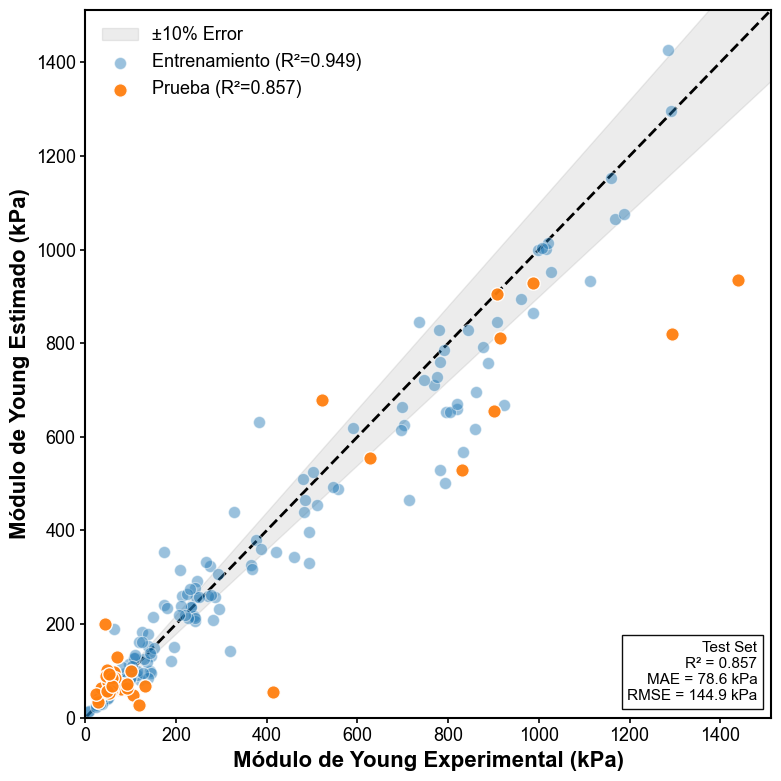

In [31]:
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

fig, ax = plt.subplots(figsize=(8,8))

max_lim = max(
    np.max(y_train),
    np.max(y_test),
    np.max(y_pred_xgb_train),
    np.max(y_pred_xgb)
)

lims = [0, max_lim * 1.05]

x_band = np.linspace(lims[0], lims[1], 500)

ax.fill_between(
    x_band,
    0.9 * x_band,
    1.1 * x_band,
    alpha=0.15,
    color='gray',
    zorder=0,
    label='±10% Error'
)

ax.plot(lims, lims, '--', color='black', lw=2, zorder=1)

ax.scatter(
    y_train, y_pred_xgb_train,
    s=75, alpha=0.45, edgecolor='white', linewidth=0.8,
    label=f'Entrenamiento (R²={r2_xgb_train:.3f})'
)

ax.scatter(
    y_test, y_pred_xgb,
    s=95, alpha=0.95, edgecolor='white', linewidth=1,
    label=f'Prueba (R²={r2_xgb:.3f})'
)

metrics_text = (
    f"Test Set\n"
    f"R² = {r2_xgb:.3f}\n"
    f"MAE = {mae_xgb:.1f} kPa\n"
    f"RMSE = {rmse_xgb:.1f} kPa"
)

ax.text(
    0.98, 0.02, metrics_text,
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=11,
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.95)
)

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Módulo de Young Experimental (kPa)', fontsize=16, fontweight='bold')
ax.set_ylabel('Módulo de Young Estimado (kPa)', fontsize=16, fontweight='bold')
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()

plt.savefig("XGBoost_Parity_Publication_LAP.png", dpi=600, bbox_inches='tight')
plt.show()

In [23]:
xgb_model = best_xgb.regressor_
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

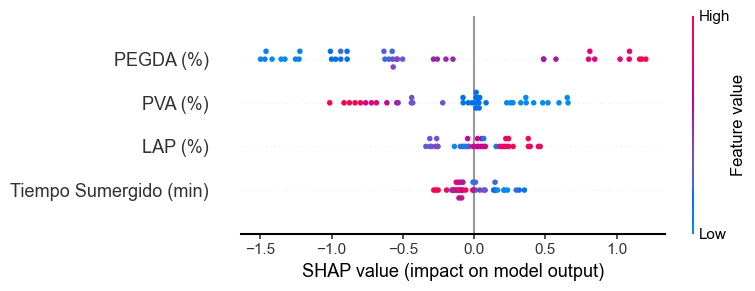

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "XGBoost_SHAP_summary.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()

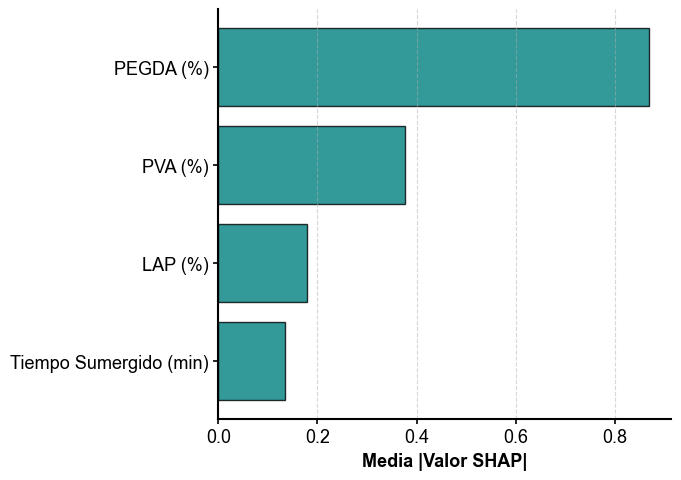

In [25]:
mean_shap = np.abs(shap_values).mean(axis=0)

importance_xgb = pd.DataFrame({
    "Variable": X_train.columns,
    "Mean_SHAP": mean_shap
})

fig, ax = plt.subplots(figsize=(7, 5))

plot_df = importance_xgb.sort_values("Mean_SHAP", ascending=True)

ax.barh(
    plot_df["Variable"], 
    plot_df["Mean_SHAP"], 
    color='teal', 
    edgecolor='black', 
    alpha=0.8
)

ax.set_xlabel("Media |Valor SHAP|", fontsize=13, fontweight="bold")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("XGBoost_SHAP_importance_LAP.tiff", dpi=600, bbox_inches="tight")
plt.show()

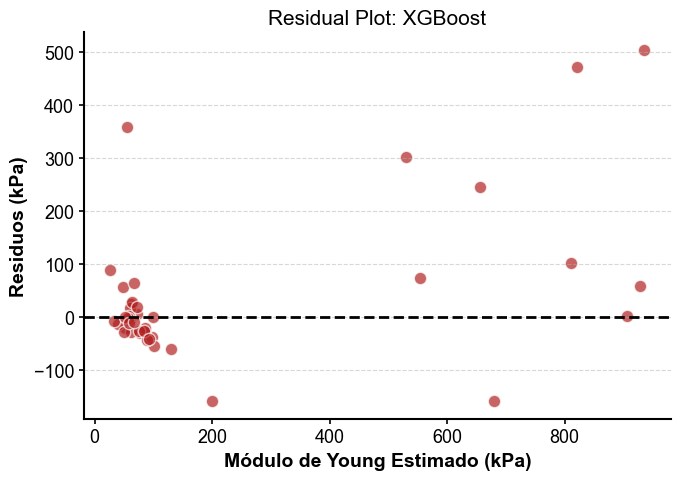

In [32]:
y_pred_xgb = best_xgb.predict(X_test)
residuals = y_test - y_pred_xgb

plt.figure(figsize=(7, 5))

plt.scatter(y_pred_xgb, residuals, alpha=0.7, color='firebrick', edgecolor='white', s=80)

plt.axhline(0, color='black', linestyle='--', lw=2)

plt.xlabel('Módulo de Young Estimado (kPa)', fontsize=14, fontweight='bold')
plt.ylabel('Residuos (kPa)', fontsize=14, fontweight='bold')
plt.title('Residual Plot: XGBoost', fontsize=15)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("XGBoost_Residuals.png", dpi=600, bbox_inches="tight")
plt.show()